# X_EXTRAS

This notebook generates a LaTeX table of observables used in the sweep tests. It reads `dd` from `recipe.py`, loads the sweep parameter JSON files, and writes the final table to `output/tex/observables_table.tex`.


## Inputs and logic

The notebook uses these inputs:

- `recipe.py` for the list of observable dictionaries `dd`
- `output/sweeps/gbm_params.json`
- `output/sweeps/qrf_params.json`
- `output/sweeps/sim_params.json`

Only observables present in at least one `obs_sel` list are included. If `sim_params.json` is missing, the SIM column defaults to `\boolFalse` for all rows. Labels found in `obs_sel` but missing from `dd` are skipped with a warning.


In [ ]:
from __future__ import annotations
import json
from pathlib import Path
from recipe import dd


def load_obs_sel(path: Path):
    if not path.exists():
        print(f"Warning: missing file {path}; using empty obs_sel")
        return []
    with path.open() as f:
        data = json.load(f)
    obs_sel = data.get("obs_sel", [])
    if obs_sel is None:
        return []
    if not isinstance(obs_sel, list):
        print(f"Warning: obs_sel in {path} is not a list; using empty obs_sel")
        return []
    return obs_sel


def latex_escape(text: str) -> str:
    return str(text).replace('_', r'\_')


def ref_to_latex(reference):
    if not reference:
        return ""
    if isinstance(reference, str):
        refs = [reference]
    elif isinstance(reference, list):
        refs = [str(r) for r in reference if r]
    else:
        refs = [str(reference)]
    refs = [r.strip() for r in refs if str(r).strip()]
    if not refs:
        return ""
    return r"\citet{" + ", ".join(refs) + "}"


def bool_tex(flag: bool) -> str:
    return r"\boolTrue" if flag else r"\boolFalse"


## Generate table

This cell reads the sweep parameter files, filters observables to those used in at least one sweep, preserves the order from `dd`, and writes the LaTeX output file.


In [2]:
root = Path('.')
sweep_dir = root / 'output' / 'sweeps'
out_path = root / 'output' / 'tex' / 'observables_table.tex'
line_end = r'\\'

gbm_obs = set(load_obs_sel(sweep_dir / 'gbm_params.json'))
qrf_obs = set(load_obs_sel(sweep_dir / 'qrf_params.json'))
sim_obs = set(load_obs_sel(sweep_dir / 'sim_params.json'))

used = gbm_obs | qrf_obs | sim_obs

rows = []
seen = set()
for item in dd:
    label = item.get('label')
    if label in used:
        seen.add(label)
        description = item.get('description', '') or ''
        reference = ref_to_latex(item.get('reference', ''))
        row = ' & '.join([
            latex_escape(label),
            description,
            bool_tex(label in gbm_obs),
            bool_tex(label in qrf_obs),
            bool_tex(label in sim_obs),
            reference,
        ]) + ' ' + line_end
        rows.append(row)

missing = sorted(used - seen)
for label in missing:
    print(f"Warning: label '{label}' present in obs_sel but missing from dd; skipping")

table = '\n'.join([
    r'\begin{table}',
    r'    \centering',
    r'    \newcolumntype{C}[1]{>{\centering\arraybackslash}p{#1}}',
    '',
    r'    \begin{tabular}{p{3cm} p{3.7cm} C{0.7cm} C{0.7cm} C{0.7cm} p{3.5cm}}',
    '',
    r'    Label & Description & GBM & QRF & SIM &  Data and processing\\',
    r'    \midrule',
    *['    ' + row for row in rows],
    r'    \bottomrule',
    r'    \end{tabular}',
    r'    \caption{Observables used.}',
    r'    \label{tab:observables}',
    r'\end{table}',
    '',
])

out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(table)
print(f"Wrote {out_path}")


Wrote output/tex/observables_table.tex


## Preview

This final cell prints the generated LaTeX so you can inspect it directly in the notebook before using it in your manuscript.


In [3]:
print(out_path.read_text())


\begin{table}
    \centering
    \newcolumntype{C}[1]{>{\centering\arraybackslash}p{#1}}

    \begin{tabular}{p{3cm} p{3.7cm} C{0.7cm} C{0.7cm} C{0.7cm} p{3.5cm}}

    Label & Description & GBM & QRF & SIM &  Data and processing\\
    \midrule
    MOHO\_GRAV & Moho depth (GEMMA gravity-derived) & \boolTrue & \boolTrue & \boolFalse & \citet{GEMMA} \\
    MOHO & Moho depth (Szwillus et al. 2019) & \boolTrue & \boolTrue & \boolFalse & \citet{Szwillus2019} \\
    DEM & ETOPO1 DEM (reference grid) & \boolTrue & \boolTrue & \boolFalse & \citet{ETOPO1} \\
    DEM & Antarctic DEM: bed topo + Paxman isostatic adjustment & \boolTrue & \boolTrue & \boolFalse &  \\
    DEM & Greenland DEM: bed topo + Paxman isostatic adjustment & \boolTrue & \boolTrue & \boolFalse &  \\
    LAB & LAB depth (LithoRef18) & \boolTrue & \boolTrue & \boolFalse & \citet{Afonso2019} \\
    CTD & Curie temperature depth (Gard & Hasterok 2021) & \boolTrue & \boolTrue & \boolFalse &  \\
    EMAG2\_LOG & EMAG2 magnetic anoma

In [ ]:
import xarray as xr
import numpy as np


<xarray.Dataset> Size: 306MB
Dimensions:       (y: 1334, x: 1334, bin: 34)
Coordinates:
  * y             (y) float64 11kB -3.332e+06 -3.327e+06 ... 3.328e+06 3.333e+06
  * x             (x) float64 11kB -3.333e+06 -3.328e+06 ... 3.327e+06 3.332e+06
  * bin           (bin) float64 272B 0.006132 0.0164 0.02666 ... 0.3346 0.3449
Data variables:
    sim_q_raw     (y, x) float32 7MB ...
    sim_q_corr    (y, x) float32 7MB ...
    sim_std_raw   (y, x) float32 7MB ...
    sim_std_corr  (y, x) float32 7MB ...
    sim_lo_raw    (y, x) float32 7MB ...
    sim_hi_raw    (y, x) float32 7MB ...
    sim_lo_corr   (y, x) float32 7MB ...
    sim_hi_corr   (y, x) float32 7MB ...
    sim_N         (y, x) float32 7MB ...
    sim_hist      (y, x, bin) float32 242MB ...
Attributes: (12/17)
    title:           Aq15_SIM heat-flow prediction
    model:           Aq15_SIM
    version:         0_3
    institution:     Stål et al. (Aq2/Kq2)
    Conventions:     CF-1.8
    crs:             EPSG:3031
    ...              ...
    hist_bin_width:  0.01
    hist_n_bins:     34
    q_clip_min:      0.001
    q_clip_max:      0.35
    shannon_H_mean:  0.48408846648487547
    spline_applied:  sim_q_corr, sim_lo_corr, sim_hi_corr

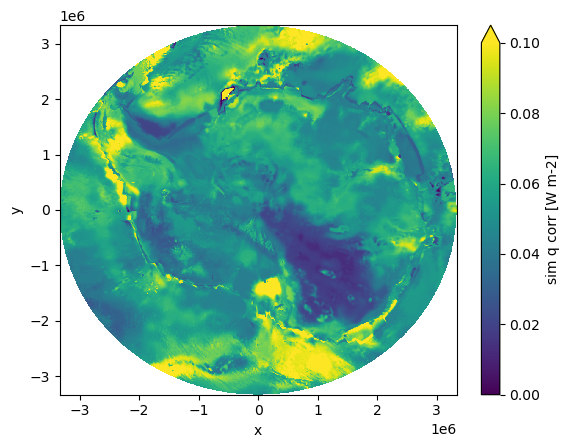

In [12]:
aq_sim = xr.open_dataset('output/targets/Aq15_SIM_v0_3.nc')
aq_sim.sim_q_corr.plot(vmin = 0, vmax = 0.10)
aq_sim 

<xarray.Dataset> Size: 93MB
Dimensions:         (y: 1334, x: 1334)
Coordinates:
  * y               (y) float64 11kB -3.332e+06 -3.327e+06 ... 3.333e+06
  * x               (x) float64 11kB -3.333e+06 -3.328e+06 ... 3.332e+06
Data variables: (12/13)
    gbm_q05_raw     (y, x) float32 7MB ...
    gbm_q50_raw     (y, x) float32 7MB ...
    gbm_q95_raw     (y, x) float32 7MB ...
    gbm_q05_corr    (y, x) float32 7MB ...
    gbm_q50_corr    (y, x) float32 7MB ...
    gbm_q95_corr    (y, x) float32 7MB ...
    ...              ...
    gbm_q95_conf    (y, x) float32 7MB ...
    gbm_iqr90_raw   (y, x) float32 7MB ...
    gbm_iqr90_corr  (y, x) float32 7MB ...
    gbm_iqr90_conf  (y, x) float32 7MB ...
    gbm_sigma_raw   (y, x) float32 7MB ...
    gbm_sigma_corr  (y, x) float32 7MB ...
Attributes: (12/16)
    title:               Aq15_GBM heat-flow prediction
    model:               Aq15_GBM
    version:             0_3
    institution:         Stål et al. (Aq2/Kq2)
    Conventions:         CF-1.8
    crs:                 EPSG:3031
    ...                  ...
    params_json:         {"model": "GBM", "sweep_notebook": "3b_GBM_SWEEP", "...
    qhatgbm_wm2:         -0.0002569080007782059
    conformal_alpha:     0.1
    spline_note:         Q50 PCHIP offset applied to Q50; same additive offse...
    shannon_H_q50_raw:   0.411805
    shannon_H_q50_corr:  0.541775

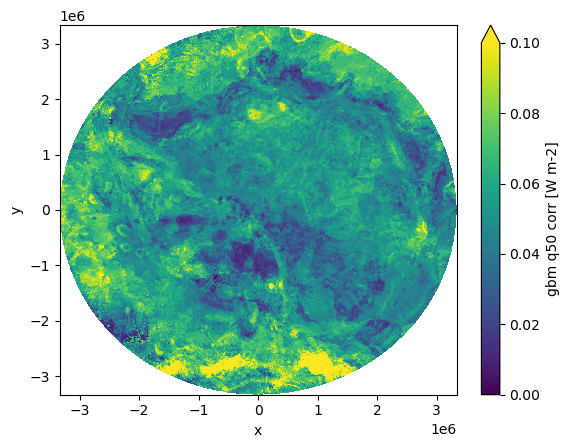

In [45]:
aq_gbm = xr.open_dataset('output/targets/Aq15_GBM_v0_3.nc')
aq_gbm.gbm_q50_corr.plot(vmin = 0, vmax = 0.10)
aq_gbm

<xarray.Dataset> Size: 114MB
Dimensions:         (y: 1334, x: 1334)
Coordinates:
  * y               (y) float64 11kB -3.332e+06 -3.327e+06 ... 3.333e+06
  * x               (x) float64 11kB -3.333e+06 -3.328e+06 ... 3.332e+06
Data variables: (12/16)
    qrf_q05_raw     (y, x) float32 7MB ...
    qrf_q05_corr    (y, x) float32 7MB ...
    qrf_q25_raw     (y, x) float32 7MB ...
    qrf_q25_corr    (y, x) float32 7MB ...
    qrf_q50_raw     (y, x) float32 7MB ...
    qrf_q50_corr    (y, x) float32 7MB ...
    ...              ...
    qrf_iqr50_raw   (y, x) float32 7MB ...
    qrf_iqr90_raw   (y, x) float32 7MB ...
    qrf_sigma_raw   (y, x) float32 7MB ...
    qrf_iqr50_corr  (y, x) float32 7MB ...
    qrf_iqr90_corr  (y, x) float32 7MB ...
    qrf_sigma_corr  (y, x) float32 7MB ...
Attributes: (12/17)
    title:               Aq1_5_QRF heat-flow prediction
    model:               Aq1_5_QRF
    version:             0_3
    institution:         Stål et al. (Aq2/Kq2)
    Conventions:         CF-1.8
    crs:                 EPSG:3031
    ...                  ...
    q_clip_min:          0.001
    q_clip_max:          0.35
    params_json:         {"model": "QRF", "sweep_notebook": "3a_QRF_SWEEP", "...
    shannon_H_q50_raw:   0.351623
    shannon_H_q50_corr:  0.381643
    spline_applied:      Q50 only; other quantiles shifted by Q50 offset

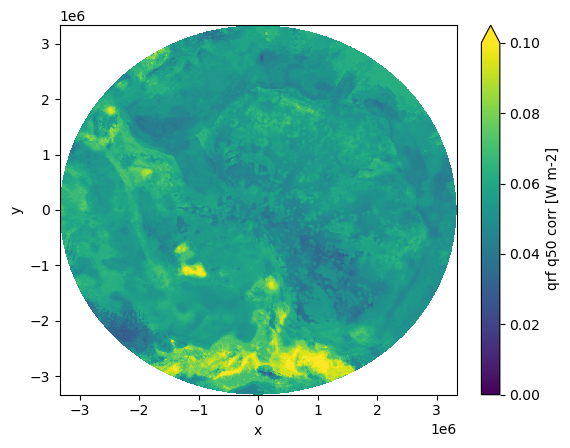

In [25]:
aq_qrf = xr.open_dataset('output/targets/Aq1_5_QRF_v0_3.nc')
aq_qrf.qrf_q50_corr.plot(vmin = 0, vmax = 0.10)
aq_qrf

In [57]:
kq_gbm = xr.open_dataset('output/targets/Kq15_GBM_v0_3.nc')
kq_qrf = xr.open_dataset('output/targets/Kq1_5_QRF_v0_3.nc')
kq_sim = xr.open_dataset('sim.nc')

agrid_kq_qrf =  grid_from_xr_dataset(kq_qrf)
agrid_kq_sim =  grid_from_xr_dataset(kq_sim)
agrid_kq_gbm =  grid_from_xr_dataset(kq_gbm)



In [58]:
from lib.utils import grid_from_xr_dataset
from config import hf_cmap, q_min, q_max


agrid_aq_qrf =  grid_from_xr_dataset(aq_qrf)
agrid_aq_sim =  grid_from_xr_dataset(aq_sim)
agrid_aq_gbm =  grid_from_xr_dataset(aq_gbm)





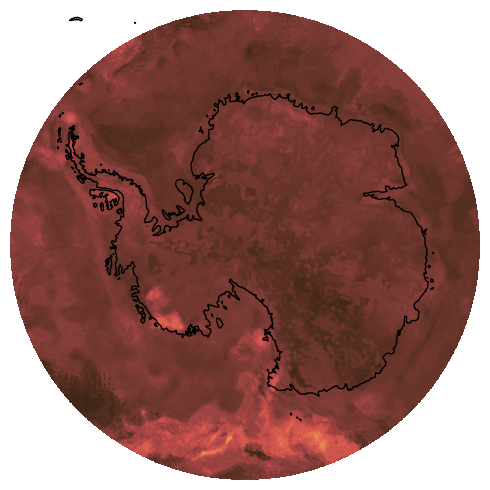

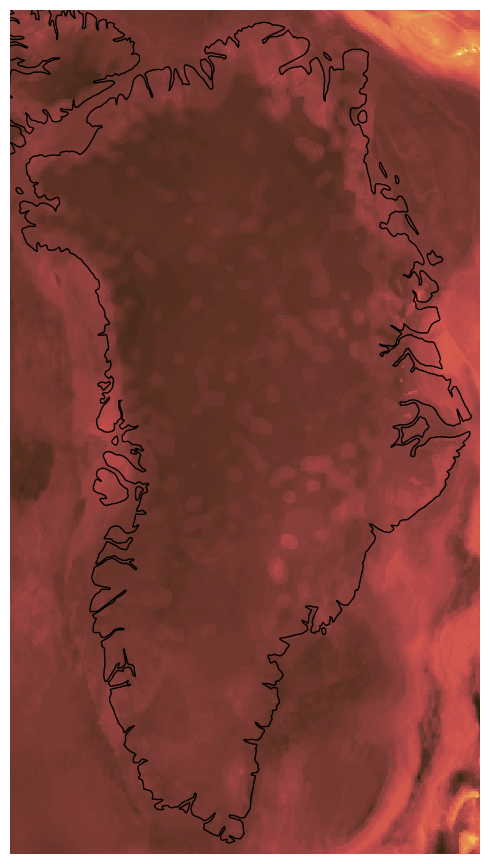

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [54]:
agrid_aq_qrf.map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='aq2_qrf_q.png')

agrid_kq_qrf.map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='kq2_qrf_q.png')

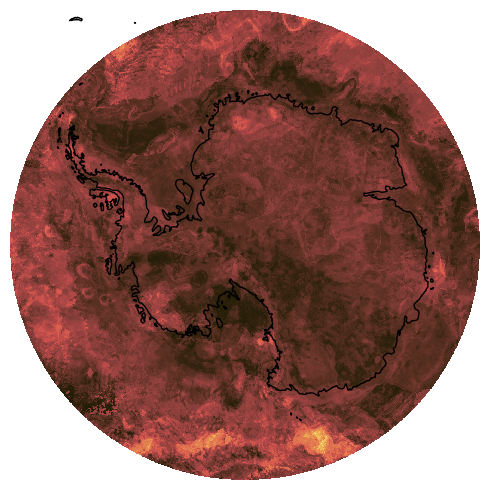

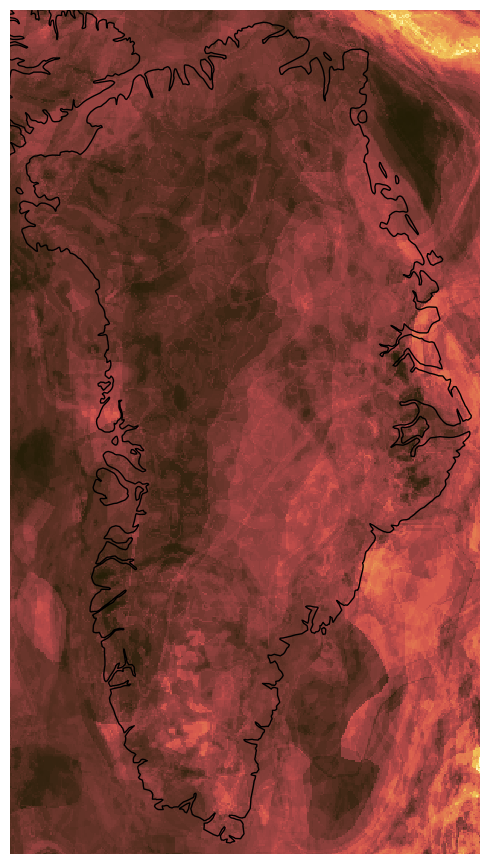

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [55]:
agrid_aq_gbm.map('gbm_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='aq2_gbm_q.png')
agrid_kq_gbm.map('gbm_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='kq2_gbm_q.png')

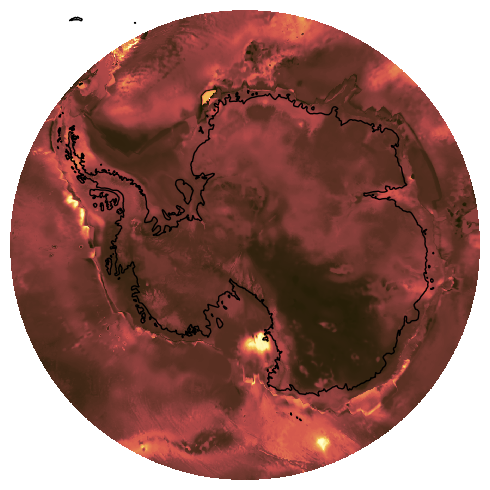

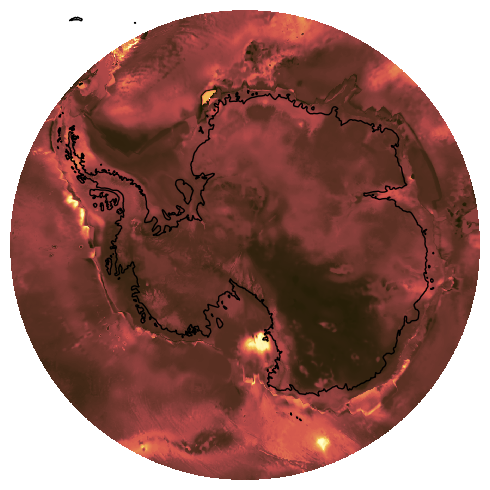

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [59]:
agrid_aq_sim.map('sim_q_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='aq2_sim_q.png')

agrid_kq_sim.map('sim_q_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, transparent=True, save_fig='kq2_sim_q.png')